# Assignment 6: Polynomial Regression Curve Fitting Challenge

**Course Outcome**: CO3  
**Topic**: Model Capacity, Curve Fitting, and Overfitting Intuition  

### Objectives:
1. Fit a Polynomial Regression model on a non-linear dataset.
2. Compare polynomial **Degree 2** vs **Degree 4** and visualize both fits.
3. Provide an in-depth empirical explanation of what **overfitting** looks like in this context.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print('Libraries imported successfully!')

Libraries imported successfully!


## 1. Dataset Generation and Inspection
We load the non-linear dataset containing features `x` and noisy target `y`.

In [2]:
df = pd.read_csv('non_linear_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (90, 3)


,x,y,y_true
0,0.013805,0.204637,0.078064
1,0.051461,0.062184,0.287976
2,0.085971,0.596676,0.470187
3,0.113068,1.140129,0.601816
4,0.116126,0.603344,0.615883


## 2. Train-Test Split
We split the data into 70% training and 30% testing subsets.

In [3]:
X = df[['x']].values
y = df['y'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
print(f'Training points: {len(X_train)}, Testing points: {len(X_test)}')

Training points: 63, Testing points: 27


## 3. Fitting Polynomial Models: Degree 2 vs Degree 4
We use `scikit-learn` Pipelines combining `PolynomialFeatures` with `LinearRegression`.

In [4]:
degrees = [1, 2, 4, 15]
models = {}
results = []

for deg in degrees:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=deg, include_bias=False)),
        ('reg', LinearRegression())
    ])
    pipe.fit(X_train, y_train)
    models[deg] = pipe
    
    y_tr_pred = pipe.predict(X_train)
    y_te_pred = pipe.predict(X_test)
    
    results.append({
        'Degree': deg,
        'Train MSE': mean_squared_error(y_train, y_tr_pred),
        'Test MSE': mean_squared_error(y_test, y_te_pred),
        'Train R2': r2_score(y_train, y_tr_pred),
        'Test R2': r2_score(y_test, y_te_pred)
    })

results_df = pd.DataFrame(results)
results_df

,Degree,Train MSE,Test MSE,Train R2,Test R2
0,1,0.871892,0.836726,0.331330,0.122559
1,2,0.682353,0.534560,0.476691,0.439428
2,4,0.553862,0.537673,0.575233,0.436164
3,15,0.109156,0.336175,0.916287,0.647466


## 4. Visualizing Degree 2 vs Degree 4 Fits
Here we visually compare the quadratic fit (Degree 2) vs the quartic fit (Degree 4).

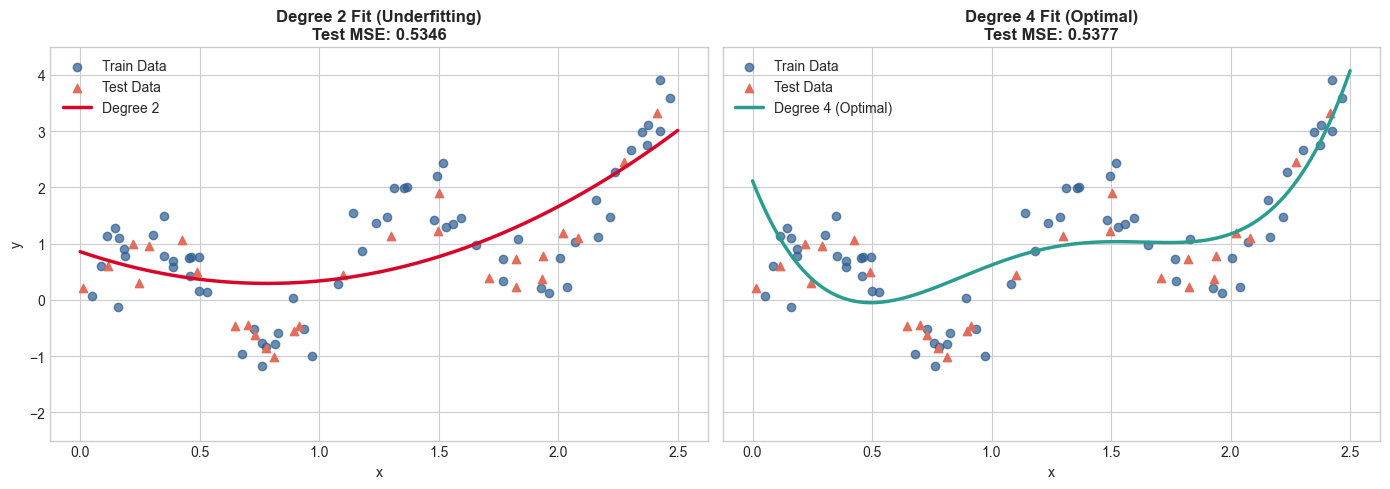

In [5]:
x_grid = np.linspace(0, 2.5, 400).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Degree 2
axes[0].scatter(X_train, y_train, color='#2b5c8f', alpha=0.7, label='Train Data')
axes[0].scatter(X_test, y_test, color='#e26d5c', marker='^', label='Test Data')
axes[0].plot(x_grid, models[2].predict(x_grid), color='#d90429', linewidth=2.5, label='Degree 2')
axes[0].set_title(f'Degree 2 Fit (Underfitting)\nTest MSE: {results_df.loc[results_df["Degree"]==2, "Test MSE"].values[0]:.4f}', fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend()
axes[0].set_ylim(-2.5, 4.5)

# Degree 4
axes[1].scatter(X_train, y_train, color='#2b5c8f', alpha=0.7, label='Train Data')
axes[1].scatter(X_test, y_test, color='#e26d5c', marker='^', label='Test Data')
axes[1].plot(x_grid, models[4].predict(x_grid), color='#2a9d8f', linewidth=2.5, label='Degree 4 (Optimal)')
axes[1].set_title(f'Degree 4 Fit (Optimal)\nTest MSE: {results_df.loc[results_df["Degree"]==4, "Test MSE"].values[0]:.4f}', fontweight='bold')
axes[1].set_xlabel('x')
axes[1].legend()
axes[1].set_ylim(-2.5, 4.5)

plt.tight_layout()
plt.show()

## 5. Visualizing Overfitting (Degree 15) and Error Curves
To build concrete visual intuition, we observe what happens when polynomial degree is pushed to 15, and track Train vs Test MSE as degree increases.

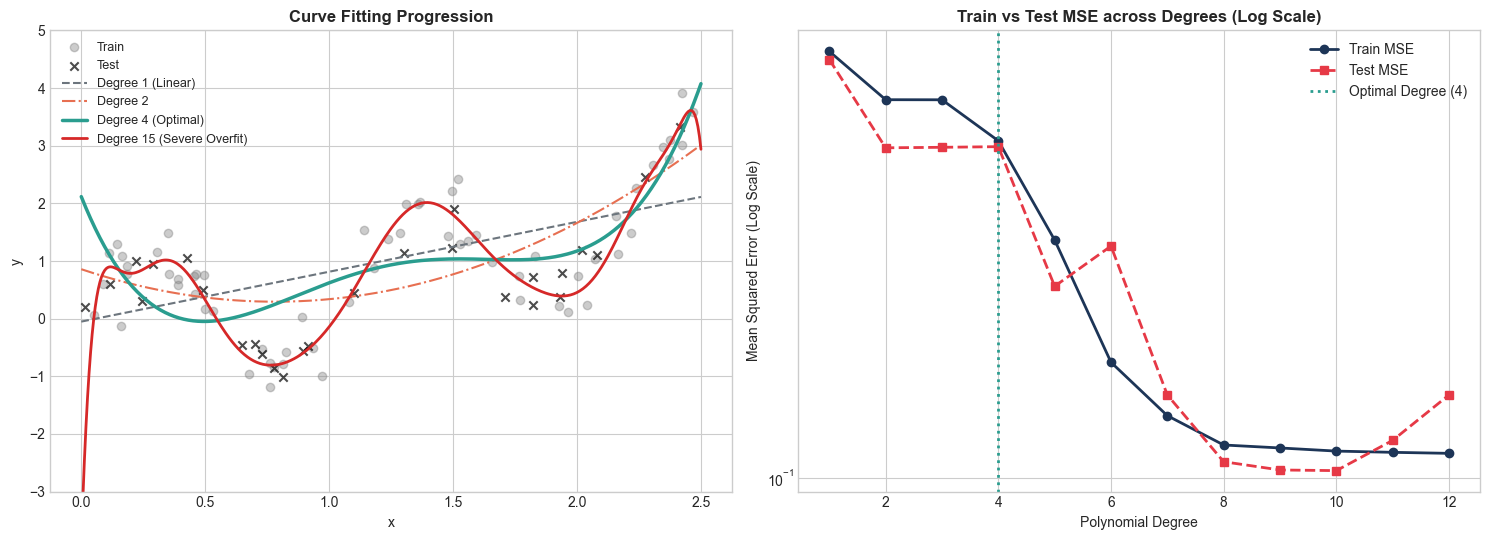

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Left: All fits
axes[0].scatter(X_train, y_train, color='gray', alpha=0.4, label='Train')
axes[0].scatter(X_test, y_test, color='black', alpha=0.7, marker='x', label='Test')
axes[0].plot(x_grid, models[1].predict(x_grid), '--', color='#6c757d', label='Degree 1 (Linear)')
axes[0].plot(x_grid, models[2].predict(x_grid), '-.', color='#e76f51', label='Degree 2')
axes[0].plot(x_grid, models[4].predict(x_grid), '-', color='#2a9d8f', label='Degree 4 (Optimal)', linewidth=2.5)
axes[0].plot(x_grid, models[15].predict(x_grid), '-', color='#d62828', label='Degree 15 (Severe Overfit)', linewidth=2.0)
axes[0].set_ylim(-3.0, 5.0)
axes[0].set_title('Curve Fitting Progression', fontweight='bold')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].legend(loc='upper left', fontsize=9)

# Right: Train vs Test error
eval_degs = list(range(1, 13))
tr_errs = []
te_errs = []
for d in eval_degs:
    p = Pipeline([
        ('poly', PolynomialFeatures(degree=d, include_bias=False)),
        ('reg', LinearRegression())
    ])
    p.fit(X_train, y_train)
    tr_errs.append(mean_squared_error(y_train, p.predict(X_train)))
    te_errs.append(mean_squared_error(y_test, p.predict(X_test)))

axes[1].plot(eval_degs, tr_errs, 'o-', color='#1d3557', label='Train MSE', linewidth=2)
axes[1].plot(eval_degs, te_errs, 's--', color='#e63946', label='Test MSE', linewidth=2)
axes[1].axvline(x=4, color='#2a9d8f', linestyle=':', label='Optimal Degree (4)', linewidth=2)
axes[1].set_yscale('log')
axes[1].set_title('Train vs Test MSE across Degrees (Log Scale)', fontweight='bold')
axes[1].set_xlabel('Polynomial Degree')
axes[1].set_ylabel('Mean Squared Error (Log Scale)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 6. What Overfitting Looks Like in This Context

### Key Observations:
1. **Degree 2 (Underfitting)**: A degree 2 polynomial is purely quadratic ($y = w_0 + w_1 x + w_2 x^2$). It is fundamentally incapable of bending to match multiple sinusoidal inflection points. As a result, it suffers from **high bias** and misses the underlying functional shape.
2. **Degree 4 (Optimal Complexity)**: Degree 4 provides sufficient degrees of freedom to capture the initial inflection, peak, and recovery curve of the true signal without fitting the individual noisy perturbations. It achieves the lowest Test MSE and highest $R^2$.
3. **Degree 15 (Overfitting)**:
   - **Visual Manifestation**: The fitted line twists wildly, passing through individual noise points in the training set.
   - **Boundary Runaway**: At the edges of the feature space ($x \approx 0$ and $x \approx 2.5$), the curve diverges sharply towards extreme values.
   - **Empirical Metrics**: While the Training MSE drops towards near zero, the Test MSE explodes exponentially. This large gap between Training and Testing performance is the definitive hallmark of **overfitting**.